# General Time Series Forecasting
NNDL final project

Angela Bortolato, ID: 2156562, Physics of Data

#### Import requirements

In [1]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [3]:
import torch
import torch.nn as nn
import os
import copy
import random
import urllib.request
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt

from utils.dataset import download_datasets, data_provider, print_dataset_summary
from models.dlinear_baseline import Model as DLinearBaseline
from models.conv1d_baseline import Model as Conv1DBaseline
from models.lstm_baseline import Model as LSTMBaseline
from models.timesnet import Model as TimesNet
from models.timesnet import ProbabilisticTimesNet
from train import train_model, train_probabilistic_model
from utils.visualization import plot_loss_trajectories, plot_forecast_comparison, visualize_raw_datasets, plot_residual_diagnostics, summarize_and_plot_experiment, plot_multi_model_horizon_comparison, extract_and_plot_fft_periods, plot_parametric_gaussian_forecast, plot_mc_dropout_forecast

In [4]:
def set_seed(seed: int = 1234):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        # Guarantees deterministic algorithms on CUDA
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)  

set_seed(1234)

#### Set up

In [5]:
# Device Selection (M5 Mac MPS / CUDA / CPU)
def get_device():
    if torch.cuda.is_available():
        device = torch.device("cuda")
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
    print(f"Using PyTorch device: {device}")
    return device

device = get_device()

Using PyTorch device: mps


## 1. Data loading

In [6]:
download_datasets("./data")

--> Found existing electricity.txt.gz in ./data
--> Found existing exchange_rate.txt.gz in ./data


In [7]:
print_dataset_summary("./data/electricity.txt.gz")
print_dataset_summary("./data/exchange_rate.txt.gz")

       DATASET METRICS SUMMARY: electricity.txt.gz
• Total Time Steps (T):      26,304
• Number of Channels/Variates (C): 321
• Total Data Points (T x C):  8,443,584
• Missing Values:            0
• Global Mean:              2538.7916
• Global Std Dev:           15027.5702
• Global Min / Max Range:   [0.0000, 764000.0000]

       DATASET METRICS SUMMARY: exchange_rate.txt.gz
• Total Time Steps (T):      7,588
• Number of Channels/Variates (C): 8
• Total Data Points (T x C):  60,704
• Missing Values:            0
• Global Mean:              0.6947
• Global Std Dev:           0.4761
• Global Min / Max Range:   [0.0063, 2.1090]



--> Electricity raw shape (Time Steps x Channels): (26304, 321)


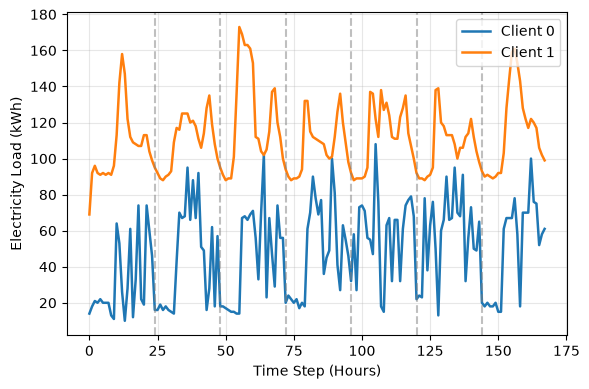

--> Exchange Rate raw shape (Time Steps x Channels): (7588, 8)


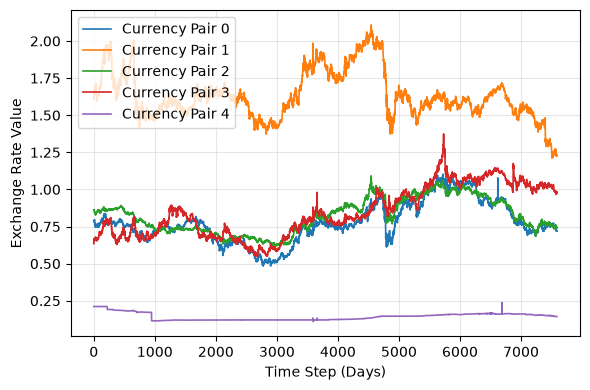

--> Raw data plots saved under './plots/'


In [8]:
visualize_raw_datasets("./data")

## 2. Baseline models

* Dlinear

In [9]:
class ConfigDLinear:
    seq_len = 96
    pred_len = 96
    moving_avg = 25
    enc_in = 321  

# Initialize Model
model_dlinear = DLinearBaseline(ConfigDLinear()).to(device)

# Dummy Lookback Tensor (Batch=32, Lookback=96, Channels=321)
dummy_x = torch.randn(32, 96, 321).to(device)

# Forward Pass
output = model_dlinear(dummy_x)

print(f"DLinear Model Loaded on Device: {device}")
print(f"Input Tensor Shape:  {dummy_x.shape}")
print(f"Output Tensor Shape: {output.shape}")  # Should be (32, 96, 321)

DLinear Model Loaded on Device: mps
Input Tensor Shape:  torch.Size([32, 96, 321])
Output Tensor Shape: torch.Size([32, 96, 321])


- Conv1d

In [10]:
class ConfigConv1D:
    seq_len = 96
    pred_len = 96
    enc_in = 321  
    kernel_size = 3
    num_layers = 2

model_conv1d = Conv1DBaseline(ConfigConv1D()).to(device)

dummy_x = torch.randn(32, 96, 321).to(device)

output = model_conv1d(dummy_x)

print(f"1D-ConvNet Model Loaded on Device: {device}")
print(f"Input Tensor Shape:  {dummy_x.shape}")
print(f"Output Tensor Shape: {output.shape}")  

1D-ConvNet Model Loaded on Device: mps
Input Tensor Shape:  torch.Size([32, 96, 321])
Output Tensor Shape: torch.Size([32, 96, 321])


- LSTM

In [11]:
class ConfigLSTM:
    seq_len = 96
    pred_len = 96
    enc_in = 321  
    hidden_dim = 128
    num_layers = 2
    dropout = 0.1

model_lstm = LSTMBaseline(ConfigLSTM()).to(device)

dummy_x = torch.randn(32, 96, 321).to(device)

output = model_lstm(dummy_x)

print(f"LSTM Model Loaded on Device: {device}")
print(f"Input Tensor Shape:  {dummy_x.shape}")
print(f"Output Tensor Shape: {output.shape}")  

LSTM Model Loaded on Device: mps
Input Tensor Shape:  torch.Size([32, 96, 321])
Output Tensor Shape: torch.Size([32, 96, 321])


## 3. TimesNet Model

In [12]:
class ConfigTimesNet:
    seq_len = 96
    pred_len = 96
    enc_in = 321    
    d_model = 64
    top_k = 5       # Top-5 periodic frequencies
    num_kernels = 6
    e_layers = 2

model_timesnet = TimesNet(ConfigTimesNet()).to(device)

dummy_x = torch.randn(32, 96, 321).to(device)

output = model_timesnet(dummy_x)

print(f"TimesNet Model Loaded on Device: {device}")
print(f"Input Tensor Shape:  {dummy_x.shape}")
print(f"Output Tensor Shape: {output.shape}")  

TimesNet Model Loaded on Device: mps
Input Tensor Shape:  torch.Size([32, 96, 321])
Output Tensor Shape: torch.Size([32, 96, 321])


## 4. Train loop: ELECTRICITY DATASET
 Test untrained models on real data

In [13]:
# ==========================================
#    TEST UNTRAINED MODELS ON REAL DATA
# ==========================================
class Config:
    root_path = './data'
    data_path = 'electricity.txt.gz'  
    seq_len = 96
    label_len = 48
    pred_len = 96
    batch_size = 32
    enc_in = 321       
    d_model = 64
    top_k = 5          # TimesNet FFT top-k periodic frequencies
    num_kernels = 6
    e_layers = 2
    hidden_dim = 128   # LSTM hidden dim
    moving_avg = 25    # DLinear moving avg kernel

args = Config()

# Get train and test DataLoaders
train_dataset, train_loader = data_provider(args, flag='train')

# Fetch one real data batch
batch_x, batch_y = next(iter(train_loader))

# Extract the target horizon ground truth: shape (B, H, C)
# batch_y initially contains (label_len + pred_len), so we slice the last pred_len steps
target_y = batch_y[:, -args.pred_len:, :].to(device)
batch_x = batch_x.to(device)

print(f"--- Real Data Batch Loaded ---")
print(f"Input batch_x shape (B, L, C):  {batch_x.shape}")
print(f"Target target_y shape (B, H, C): {target_y.shape}\n")

# Native MSE Loss module
criterion = nn.MSELoss()

models = {
    "DLinear": DLinearBaseline(args).to(device),
    "1D-ConvNet": Conv1DBaseline(args).to(device),
    "LSTM": LSTMBaseline(args).to(device),
    "TimesNet": TimesNet(args).to(device)
}

print("=" * 60)
print(f"{'Model Name':<15} | {'Output Shape':<18} | {'Initial MSE Loss':<15}")
print("=" * 60)

for name, model in models.items():
    model.eval()  
    with torch.no_grad():
        # Forward pass on real input batch
        output = model(batch_x)
        
        # Calculate initial MSE loss
        loss = criterion(output, target_y).item()
        
        print(f"{name:<15} | {str(tuple(output.shape)):<18} | {loss:.4f}")

print("=" * 60)

--- Real Data Batch Loaded ---
Input batch_x shape (B, L, C):  torch.Size([32, 96, 321])
Target target_y shape (B, H, C): torch.Size([32, 96, 321])

Model Name      | Output Shape       | Initial MSE Loss
DLinear         | (32, 96, 321)      | 2.2016
1D-ConvNet      | (32, 96, 321)      | 1.2744
LSTM            | (32, 96, 321)      | 0.8678
TimesNet        | (32, 96, 321)      | 1.1574


#### Proper training loop

In [14]:
# ==========================================
# Experiment Configuration
# ==========================================
class ElectricityConfig:
    # Dataset & Paths
    root_path = './data'
    data_path = 'electricity.txt.gz'
    
    # Time Windows
    seq_len = 96
    label_len = 48
    pred_len = 96
    
    # Model Architecture Specs
    enc_in = 321          # Total channels in Electricity dataset
    
    # TimesNet Hyperparameters (Tuned for Mac MPS)
    top_k = 5             # Paper standard for Electricity 
    d_model = 64          # Feature capacity 64
    num_kernels = 4       
    e_layers = 2          # Official 2-layer TimesBlock stack
    use_revin = True      # technique for time-series forecasting to handle distribution shifts
    
    # Baseline Hyperparameters
    hidden_dim = 128      # LSTM hidden dimension
    moving_avg = 25       # DLinear moving average kernel size
    
    # Training Optimization
    batch_size = 32       # Optimal batch size for Apple Silicon UMA
    train_epochs = 10     # Total training epochs
    learning_rate = 0.001 # Initial LR (handled by ReduceLROnPlateau)

args = ElectricityConfig()

# Dictionary of models to train
experiments = {
    "DLinear": DLinearBaseline(args),
    "1D-ConvNet": Conv1DBaseline(args),
    "LSTM": LSTMBaseline(args),
    "TimesNet": TimesNet(args)
}


In [15]:
checkpoint_dir = "./checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

metrics_path = os.path.join(checkpoint_dir, "all_results_electricity.npy")

#  Initialize or Load Existing Results Dictionary
if os.path.exists(metrics_path):
    all_results = np.load(metrics_path, allow_pickle=True).item()
    print("--> Loaded existing benchmark results from disk.")
else:
    all_results = {}

force_recompute = False  # Set to True to force re-training/evaluation of metrics even if weights exist
# ----------------------------------------------------
#  Main Loop: Load Checkpoint or Train
# ----------------------------------------------------
for name, model_instance in experiments.items():
    args.model_name = name
    weights_path = os.path.join(checkpoint_dir, f"{name}_electricity.pt")
    model_gpu = model_instance.to(device)
    
    # Check if pre-trained weights exist on disk
    if os.path.exists(weights_path) and not force_recompute:
        print(f"--> [FOUND] Loading pre-trained weights for '{name}' from: {weights_path}")
        model_gpu.load_state_dict(torch.load(weights_path, map_location=device))
        model_gpu.eval()
        
        # If metrics were missing from dictionary for some reason, retrain+evaluate to populate
        if name not in all_results:
            print(f"    Evaluating '{name}' on test set to compute metrics...")
            res = train_model(model_gpu, args, device)
            all_results[name] = res
            
    else:
        print(f"\n==================================================")
        print(f"--> [NOT FOUND] Checkpoint missing for '{name}'. Starting training...")
        print(f"==================================================")
        
        # Train model
        res = train_model(model_gpu, args, device)
        all_results[name] = res
        
        # Save weights immediately after training
        torch.save(model_gpu.state_dict(), weights_path)
        print(f"--> Saved best {name} model weights to: {weights_path}\n")

#  Save/Update Complete Results Dictionary
np.save(metrics_path, all_results)
print("--> Updated and saved complete benchmark results dictionary to:", metrics_path)

--> Loaded existing benchmark results from disk.
--> [FOUND] Loading pre-trained weights for 'DLinear' from: ./checkpoints/DLinear_electricity.pt
--> [FOUND] Loading pre-trained weights for '1D-ConvNet' from: ./checkpoints/1D-ConvNet_electricity.pt
--> [FOUND] Loading pre-trained weights for 'LSTM' from: ./checkpoints/LSTM_electricity.pt
--> [FOUND] Loading pre-trained weights for 'TimesNet' from: ./checkpoints/TimesNet_electricity.pt
--> Updated and saved complete benchmark results dictionary to: ./checkpoints/all_results_electricity.npy


In [16]:
summary_data = []
for name, res in all_results.items():
    summary_data.append({
        "Model": res["model"],
        "Horizon (H)": res["pred_len"],
        "Test MSE": f"{res['test_mse']:.4f}",
        "Test MAE": f"{res['test_mae']:.4f}"
    })

df_summary = pd.DataFrame(summary_data)
print("=" * 45)
print("       ELECTRICITY BENCHMARK SUMMARY")
print("=" * 45)
print(df_summary.to_string(index=False))
print("=" * 45)

       ELECTRICITY BENCHMARK SUMMARY
     Model  Horizon (H) Test MSE Test MAE
   DLinear           96   0.1953   0.2788
1D-ConvNet           96   0.2112   0.3120
      LSTM           96   0.3599   0.4212
  TimesNet           96   0.1714   0.2751


## 5. Results 

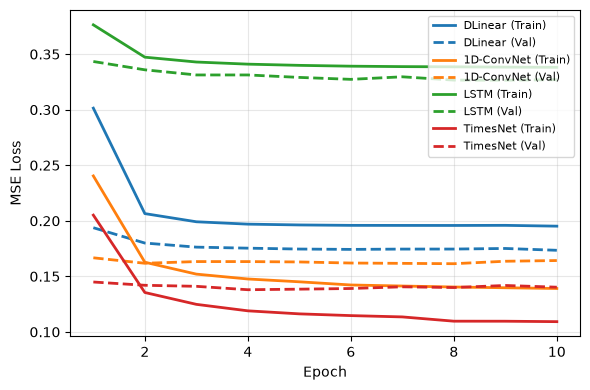

--> Loss trajectory plot saved to ./plots/ele_loss_trajectories.png


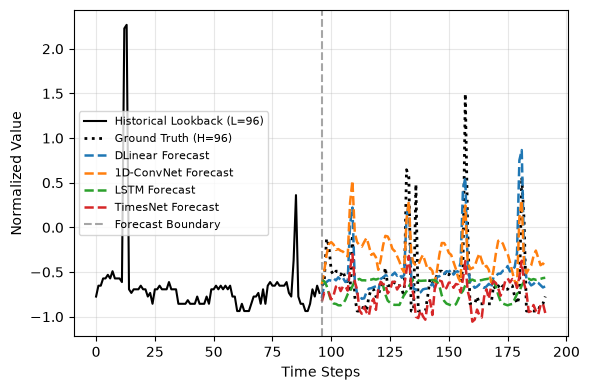

--> Forecast visual plot saved to ./plots/ele_forecast_comparison.png


In [17]:
# Plot Training & Validation Loss Curves
plot_loss_trajectories(all_results, save_path="./plots/ele_loss_trajectories.png")

# Get Test DataLoader instance for visual evaluation
test_dataset, test_loader = data_provider(args, flag='test')

# Plot Forecast Comparison against Ground Truth
plot_forecast_comparison(
    models_dict=experiments,
    test_loader=test_loader,
    device=device,
    sample_idx=0,      
    channel_idx=0,     
    seq_len=args.seq_len,
    pred_len=args.pred_len,
    save_path="./plots/ele_forecast_comparison.png"
)

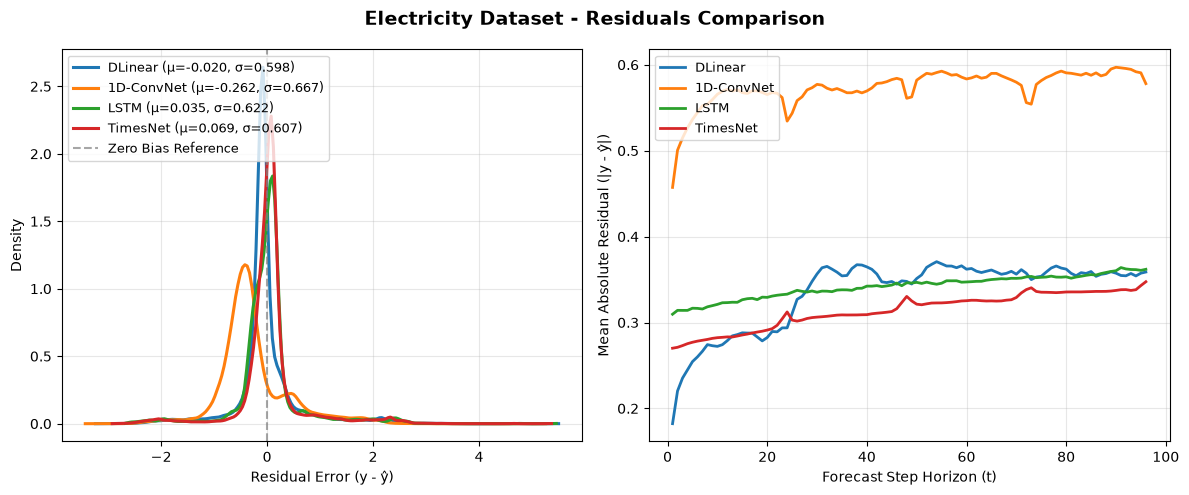

--> Multi-model residual diagnostics saved to: ./plots/ele_residuals.png


In [18]:
plot_residual_diagnostics(experiments, test_loader, device, dataset_name="Electricity", save_path="./plots/ele_residuals.png")

## 6. Model analysis

### Time horizon generalization

In [19]:
base_args = ElectricityConfig()
horizons = [96, 192, 336, 720]

checkpoint_dir = "./checkpoints/horizons"
os.makedirs(checkpoint_dir, exist_ok=True)

metrics_path = os.path.join(checkpoint_dir, "ele_horizon_results.npy")

# Define factory functions for all models
model_factories = {
    "TimesNet": lambda cfg: TimesNet(cfg),
    "DLinear": lambda cfg: DLinearBaseline(cfg),
    "1D-ConvNet": lambda cfg: Conv1DBaseline(cfg),
    "LSTM": lambda cfg: LSTMBaseline(cfg)
}

# Load existing master results dictionary if available
if os.path.exists(metrics_path):
    all_horizon_results = np.load(metrics_path, allow_pickle=True).item()
    print("--> Loaded existing multi-model horizon results from disk.")
else:
    # Outer key: model_name, Inner key: horizon H
    all_horizon_results = {model_name: {} for model_name in model_factories.keys()}

print(f"\nRunning Horizon Generalization Study on {device}...")
print(f"Fixed Lookback L = {base_args.seq_len} | Horizons H = {horizons}\n")

force_recompute = False

# ----------------------------------------------------
#  Main Loop Across Models and Horizons
# ----------------------------------------------------
for model_name, factory in model_factories.items():
    if model_name not in all_horizon_results:
        all_horizon_results[model_name] = {}
        
    for H in horizons:
        checkpoint_path = os.path.join(checkpoint_dir, f"{model_name}_electricity_H{H}.pt")
        
        # Configure arguments for current horizon H
        args = copy.deepcopy(base_args)
        args.pred_len = H
        args.train_epochs = 7  
        args.model_name = f"{model_name}_H{H}"
        
        model = factory(args).to(device)
        
        # --- CASE A: Checkpoint Exists -> Load Weights ---
        if os.path.exists(checkpoint_path) and not force_recompute:
            print(f"--> [FOUND] Loading {model_name} (H={H}) from: {checkpoint_path}")
            model.load_state_dict(torch.load(checkpoint_path, map_location=device))
            model.eval()
            
            # Populate metrics if missing from dictionary by retraining and evaluating
            if H not in all_horizon_results[model_name]:
                print(f"    Evaluating {model_name} (H={H}) on test set...")
                res = train_model(model, args, device)
                all_horizon_results[model_name][H] = res
                
        # --- CASE B: Checkpoint Missing -> Train Model ---
        else:
            print(f"\n==================================================")
            print(f"--> [NOT FOUND] Training {model_name} for Horizon H = {H}...")
            print(f"==================================================")
            
            # Train model
            res = train_model(model, args, device)
            all_horizon_results[model_name][H] = res
            
            # Save checkpoint immediately
            torch.save(model.state_dict(), checkpoint_path)
            print(f"--> Saved checkpoint to {checkpoint_path}\n")

# ----------------------------------------------------
#  Save Master Metrics Dictionary
# ----------------------------------------------------
np.save(metrics_path, all_horizon_results)
print("--> Updated complete multi-model horizon results dictionary at:", metrics_path)

--> Loaded existing multi-model horizon results from disk.

Running Horizon Generalization Study on mps...
Fixed Lookback L = 96 | Horizons H = [96, 192, 336, 720]

--> [FOUND] Loading TimesNet (H=96) from: ./checkpoints/horizons/TimesNet_electricity_H96.pt
--> [FOUND] Loading TimesNet (H=192) from: ./checkpoints/horizons/TimesNet_electricity_H192.pt
--> [FOUND] Loading TimesNet (H=336) from: ./checkpoints/horizons/TimesNet_electricity_H336.pt
--> [FOUND] Loading TimesNet (H=720) from: ./checkpoints/horizons/TimesNet_electricity_H720.pt
--> [FOUND] Loading DLinear (H=96) from: ./checkpoints/horizons/DLinear_electricity_H96.pt
--> [FOUND] Loading DLinear (H=192) from: ./checkpoints/horizons/DLinear_electricity_H192.pt
--> [FOUND] Loading DLinear (H=336) from: ./checkpoints/horizons/DLinear_electricity_H336.pt
--> [FOUND] Loading DLinear (H=720) from: ./checkpoints/horizons/DLinear_electricity_H720.pt
--> [FOUND] Loading 1D-ConvNet (H=96) from: ./checkpoints/horizons/1D-ConvNet_electrici


       MULTI-MODEL HORIZON GENERALIZATION SUMMARY (TEST MSE)
Horizon (H) 96 (MSE) 192 (MSE) 336 (MSE) 720 (MSE) TimesNet (MSE) DLinear (MSE) 1D-ConvNet (MSE) LSTM (MSE)
       H=96      N/A       N/A       N/A       N/A         0.1751        0.1961           0.2112     0.3606
      H=192      N/A       N/A       N/A       N/A         0.1863        0.1961           0.2063     0.3753
      H=336      N/A       N/A       N/A       N/A         0.3760        0.2082           0.2119     0.3741
      H=720      N/A       N/A       N/A       N/A         0.8827        0.2441           0.2542     0.4027



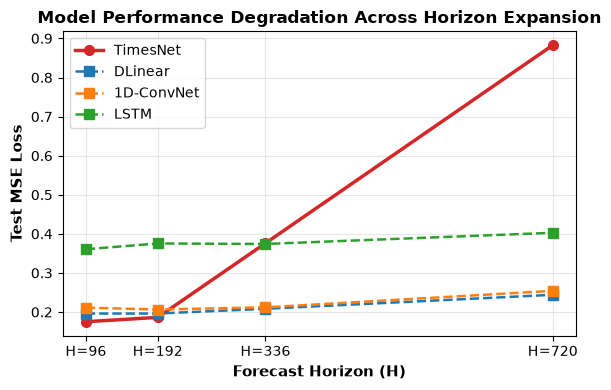

--> Saved horizon comparison plot to: ./plots/ele_horizon_benchmark.png


In [20]:
plot_multi_model_horizon_comparison(
    all_horizon_results,
    horizons,
    save_path="./plots/ele_horizon_benchmark.png"
)

### Top k ablation

In [21]:
base_args = ElectricityConfig()
k_values = [1, 3, 5, 7]

checkpoint_dir = "./checkpoints/topk_ablation"
os.makedirs(checkpoint_dir, exist_ok=True)

metrics_path = os.path.join(checkpoint_dir, "ele_topk_results.npy")

if os.path.exists(metrics_path):
    topk_results = np.load(metrics_path, allow_pickle=True).item()
    print("--> Loaded existing Top-k ablation results from disk.")
else:
    topk_results = {}

print(f"\nRunning Top-k Ablation Study on {device}...")
print(f"Fixed Horizon H = {base_args.pred_len} | k values = {k_values}\n")

force_recompute = False

# ----------------------------------------------------
#  Main Loop Across Top-k Configurations
# ----------------------------------------------------
for k in k_values:
    checkpoint_path = os.path.join(checkpoint_dir, f"TimesNet_electricity_k{k}.pt")
    
    args = copy.deepcopy(base_args)
    args.top_k = k
    args.train_epochs = 7       
    args.model_name = f"TimesNet_k{k}"
    
    model = TimesNet(args).to(device)
    
    if os.path.exists(checkpoint_path) and not force_recompute:
        print(f"--> [FOUND] Loading TimesNet (k={k}) from: {checkpoint_path}")
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        model.eval()
        
        if k not in topk_results:
            print(f"    Evaluating TimesNet (k={k}) on test set...")
            res = train_model(model, args, device)
            topk_results[k] = res
            
    else:
        print(f"\n==================================================")
        print(f"--> [NOT FOUND] Training TimesNet for top_k = {k}...")
        print(f"==================================================")
        
        # Train model
        res = train_model(model, args, device)
        topk_results[k] = res
        
        # Save checkpoint immediately
        torch.save(model.state_dict(), checkpoint_path)
        print(f"--> Saved checkpoint to {checkpoint_path}\n")

#  Save Master Metrics Dictionary
np.save(metrics_path, topk_results)
print("\n--> Updated and saved complete Top-k ablation results dictionary to:", metrics_path)

--> Loaded existing Top-k ablation results from disk.

Running Top-k Ablation Study on mps...
Fixed Horizon H = 96 | k values = [1, 3, 5, 7]

--> [FOUND] Loading TimesNet (k=1) from: ./checkpoints/topk_ablation/TimesNet_electricity_k1.pt
--> [FOUND] Loading TimesNet (k=3) from: ./checkpoints/topk_ablation/TimesNet_electricity_k3.pt
--> [FOUND] Loading TimesNet (k=5) from: ./checkpoints/topk_ablation/TimesNet_electricity_k5.pt
--> [FOUND] Loading TimesNet (k=7) from: ./checkpoints/topk_ablation/TimesNet_electricity_k7.pt

--> Updated and saved complete Top-k ablation results dictionary to: ./checkpoints/topk_ablation/ele_topk_results.npy



       TIMESNET SENSITIVITY TO PERIOD FREQUENCY DEPTH (K) SUMMARY
top_k Test MSE Test MAE Best Val MSE
  k=1   0.1800   0.2787       0.1369
  k=3   0.1736   0.2776       0.1384
  k=5   0.1744   0.2785       0.1388
  k=7   0.1741   0.2781       0.1393



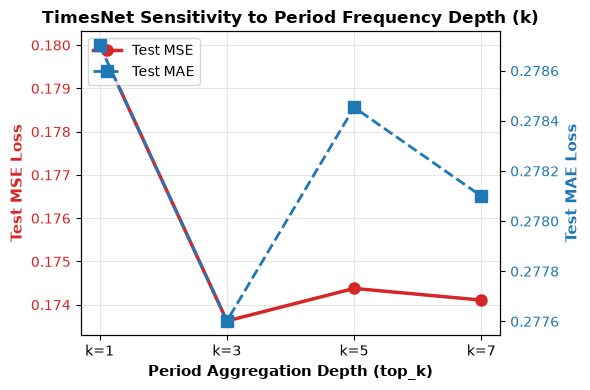

--> Saved plot to: ./plots/ele_topk_ablation.png


In [22]:
summarize_and_plot_experiment(
    results_dict=topk_results,
    param_name="top_k",
    title="TimesNet Sensitivity to Period Frequency Depth (k)",
    xlabel="Period Aggregation Depth (top_k)",
    save_path="./plots/ele_topk_ablation.png",
    plot_type="line",
    prefix="k="
)

### RevIN ablation

In [23]:
base_args = ElectricityConfig()
revin_settings = [True, False]

checkpoint_dir = "./checkpoints/revin_ablation"
os.makedirs(checkpoint_dir, exist_ok=True)

metrics_path = os.path.join(checkpoint_dir, "ele_revin_results.npy")

if os.path.exists(metrics_path):
    revin_results = np.load(metrics_path, allow_pickle=True).item()
    print("--> Loaded existing RevIN ablation results from disk.")
else:
    revin_results = {}

print(f"\nRunning RevIN Ablation Study on {device}...")
print(f"Testing RevIN Enabled vs. Disabled | Horizon H = {base_args.pred_len}\n")

force_recompute = False

# ----------------------------------------------------
# Main Loop Across RevIN Configurations
# ----------------------------------------------------
for use_revin in revin_settings:
    setting_name = "With_RevIN" if use_revin else "Without_RevIN"
    checkpoint_path = os.path.join(checkpoint_dir, f"TimesNet_electricity_{setting_name}.pt")
    
    args = copy.deepcopy(base_args)
    args.use_revin = use_revin
    args.train_epochs = 7       
    args.model_name = f"TimesNet_{setting_name}"
    
    model = TimesNet(args).to(device)
    
    if os.path.exists(checkpoint_path) and not force_recompute:
        print(f"--> [FOUND] Loading TimesNet ({setting_name}) from: {checkpoint_path}")
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        model.eval()
        
        if setting_name not in revin_results:
            print(f"    Evaluating TimesNet ({setting_name}) on test set...")
            res = train_model(model, args, device)
            revin_results[setting_name] = res
            
    else:
        print(f"\n==================================================")
        print(f"--> [NOT FOUND] Training TimesNet for {setting_name}...")
        print(f"==================================================")
        
        res = train_model(model, args, device)
        revin_results[setting_name] = res
        
        torch.save(model.state_dict(), checkpoint_path)
        print(f"--> Saved checkpoint to {checkpoint_path}\n")

# Save Master Metrics Dictionary
np.save(metrics_path, revin_results)
print("\n--> Updated and saved complete RevIN ablation results dictionary to:", metrics_path)

--> Loaded existing RevIN ablation results from disk.

Running RevIN Ablation Study on mps...
Testing RevIN Enabled vs. Disabled | Horizon H = 96

--> [FOUND] Loading TimesNet (With_RevIN) from: ./checkpoints/revin_ablation/TimesNet_electricity_With_RevIN.pt
--> [FOUND] Loading TimesNet (Without_RevIN) from: ./checkpoints/revin_ablation/TimesNet_electricity_Without_RevIN.pt

--> Updated and saved complete RevIN ablation results dictionary to: ./checkpoints/revin_ablation/ele_revin_results.npy



       IMPACT OF REVIN ON CONVERGENCE AND TEMPORAL DRIFT SUMMARY
      Setting Test MSE Test MAE Best Val MSE
   With_RevIN   0.1736   0.2782       0.1379
Without_RevIN   0.4915   0.5169       0.1950

--> RevIN Reduced Test Error (MSE) by: 64.67%



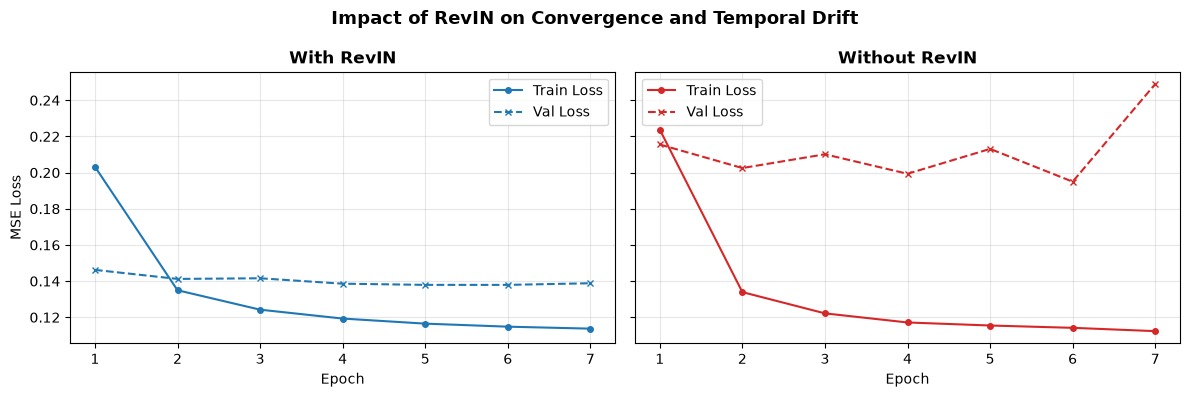

--> Saved plot to: ./plots/ele_revin_ablation.png


In [24]:
summarize_and_plot_experiment(
    results_dict=revin_results,
    param_name="Setting",
    title="Impact of RevIN on Convergence and Temporal Drift",
    save_path="./plots/ele_revin_ablation.png",
    plot_type="trajectories"
)

### FFT frequencies 


   TIMESNET FFT DOMAIN INTERPRETABILITY (L=96)
Rank   | Freq Index   | Period (Steps)   | Period (Hours)   | Amplitude 
------------------------------------------------------------------------
1      | 4            | 24.00            | 24.00           h | 29.1923   
2      | 8            | 12.00            | 12.00           h | 13.2215   
3      | 1            | 96.00            | 96.00           h | 6.8599    
4      | 12           | 8.00             | 8.00            h | 5.2239    
5      | 16           | 6.00             | 6.00            h | 4.6226    



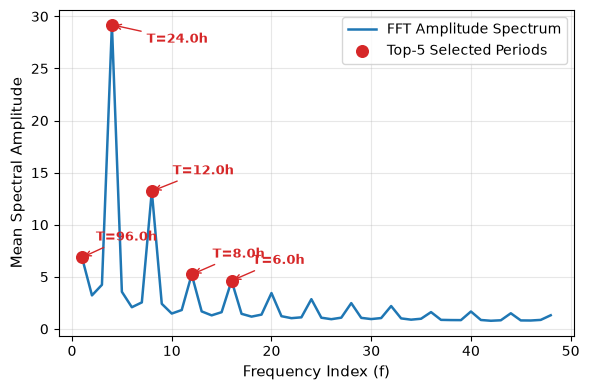

--> Saved FFT Period Analysis Plot to: ./plots/ele_fft_periods.png


In [25]:
model= TimesNet(base_args).to(device)
model.load_state_dict(torch.load("./checkpoints/TimesNet_electricity.pt", map_location=device))
model.eval()

with torch.no_grad():
    extract_and_plot_fft_periods(model, test_loader, device, top_k=5, save_path="./plots/ele_fft_periods.png")

## Another dataset: EXCHANGE RATES (Finance)
Financial exchange rates typically behave like random walks with strong macro trends and low periodic structure.

## Training loop

In [26]:
# ==========================================
# Financial Dataset Configuration
# ==========================================
class FinancialConfig:
    root_path = './data'
    data_path = 'exchange_rate.txt.gz'  # Financial dataset
    seq_len = 96
    label_len = 48
    pred_len = 96
    batch_size = 32
    enc_in = 8            # 8 Foreign Currency Pairs
    d_model = 36
    top_k = 5             # Lower top-k for noisy financial series
    num_kernels = 3
    e_layers = 2
    use_revin = True      
    hidden_dim = 32       
    moving_avg = 25       
    train_epochs = 15     
    learning_rate = 0.001

fin_args = FinancialConfig()

checkpoint_dir = "./checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

metrics_path = os.path.join(checkpoint_dir, "all_results_exchange_rate.npy")

if os.path.exists(metrics_path):
    fin_results = np.load(metrics_path, allow_pickle=True).item()
    print("--> Loaded existing financial benchmark results from disk.")
else:
    fin_results = {}

fin_experiments = {
    "DLinear": DLinearBaseline(fin_args),
    "1D-ConvNet": Conv1DBaseline(fin_args),
    "LSTM": LSTMBaseline(fin_args),
    "TimesNet": TimesNet(fin_args)
}

print(f"\nRunning Financial Benchmark ({fin_args.data_path}) on {device}...\n")

force_recompute = False

# ==========================================
#  Main Loop: Check Checkpoint or Train
# ==========================================
for name, model_instance in fin_experiments.items():
    fin_args.model_name = name
    checkpoint_path = os.path.join(checkpoint_dir, f"{name}_exchange_rate.pt")
    model_gpu = model_instance.to(device)
    
    # --- CASE A: Checkpoint Exists -> Load Weights ---
    if os.path.exists(checkpoint_path) and not force_recompute:
        print(f"--> [FOUND] Loading pre-trained weights for '{name}' from: {checkpoint_path}")
        model_gpu.load_state_dict(torch.load(checkpoint_path, map_location=device))
        model_gpu.eval()
        
        if name not in fin_results:
            print(f"    Evaluating '{name}' on test set to compute metrics...")
            res = train_model(model_gpu, fin_args, device)
            fin_results[name] = res
            
    # --- CASE B: Checkpoint Missing -> Train Model ---
    else:
        print(f"\n==================================================")
        print(f"--> [NOT FOUND] Checkpoint missing for '{name}'. Starting training...")
        print(f"==================================================")
        
        res = train_model(model_gpu, fin_args, device)
        fin_results[name] = res
        
        torch.save(model_gpu.state_dict(), checkpoint_path)
        print(f"--> Saved best {name} model weights to: {checkpoint_path}\n")

# ==========================================
# Save Master Metrics Dictionary
# ==========================================
np.save(metrics_path, fin_results)
print("\n--> Updated and saved complete financial benchmark results dictionary to:", metrics_path)

--> Loaded existing financial benchmark results from disk.

Running Financial Benchmark (exchange_rate.txt.gz) on mps...

--> [FOUND] Loading pre-trained weights for 'DLinear' from: ./checkpoints/DLinear_exchange_rate.pt
--> [FOUND] Loading pre-trained weights for '1D-ConvNet' from: ./checkpoints/1D-ConvNet_exchange_rate.pt
--> [FOUND] Loading pre-trained weights for 'LSTM' from: ./checkpoints/LSTM_exchange_rate.pt
--> [FOUND] Loading pre-trained weights for 'TimesNet' from: ./checkpoints/TimesNet_exchange_rate.pt

--> Updated and saved complete financial benchmark results dictionary to: ./checkpoints/all_results_exchange_rate.npy


In [27]:
fin_summary_data = []
for name, res in fin_results.items():
    fin_summary_data.append({
        "Model": res["model"],
        "Dataset": "Exchange Rate",
        "Horizon (H)": res["pred_len"],
        "Test MSE": f"{res['test_mse']:.4f}",
        "Test MAE": f"{res['test_mae']:.4f}"
    })

df_fin_summary = pd.DataFrame(fin_summary_data)
print("=" * 55)
print("     FINANCIAL BENCHMARK SUMMARY (Exchange Rate)")
print("=" * 55)
print(df_fin_summary.to_string(index=False))
print("=" * 55)

     FINANCIAL BENCHMARK SUMMARY (Exchange Rate)
     Model       Dataset  Horizon (H) Test MSE Test MAE
   DLinear Exchange Rate           96   0.0787   0.1999
1D-ConvNet Exchange Rate           96   0.0963   0.2388
      LSTM Exchange Rate           96   0.1158   0.2414
  TimesNet Exchange Rate           96   0.1452   0.2771


## Results

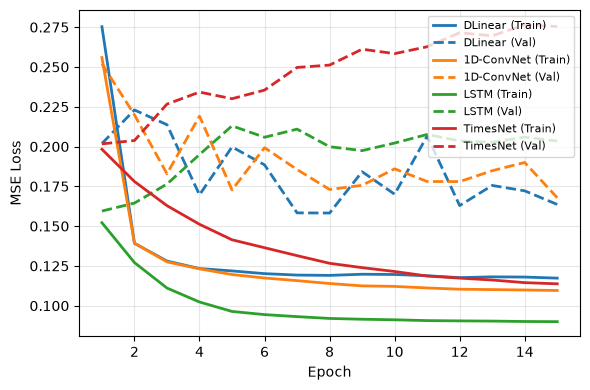

--> Loss trajectory plot saved to ./plots/fin_loss_trajectories.png


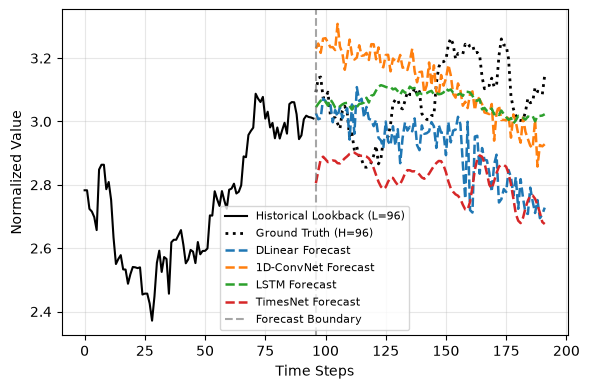

--> Forecast visual plot saved to ./plots/fin_forecast_comparison.png


In [28]:

plot_loss_trajectories(fin_results, dataset_name="Exchange Rate", save_path="./plots/fin_loss_trajectories.png")

fin_test_dataset, fin_test_loader = data_provider(fin_args, flag='test')

plot_forecast_comparison(
    models_dict=fin_experiments,
    test_loader=fin_test_loader,
    device=device,
    sample_idx=0,
    channel_idx=3,
    seq_len=fin_args.seq_len,
    pred_len=fin_args.pred_len,
    dataset_name="Exchange Rate",
    save_path="./plots/fin_forecast_comparison.png"
)

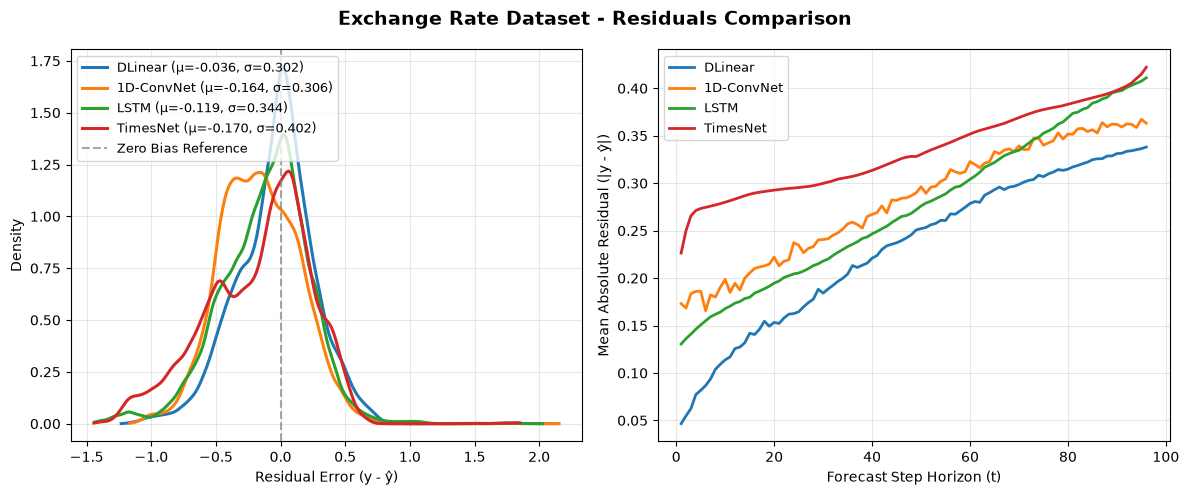

--> Multi-model residual diagnostics saved to: ./plots/fin_residuals.png


In [29]:
plot_residual_diagnostics(fin_experiments, fin_test_loader, device, dataset_name="Exchange Rate", save_path="./plots/fin_residuals.png")

## Model analysis

### Horizon generalization

In [30]:
base_args = FinancialConfig()
horizons = [96, 192, 336, 720]

checkpoint_dir = "./checkpoints/horizons"
os.makedirs(checkpoint_dir, exist_ok=True)

metrics_path = os.path.join(checkpoint_dir, "fin_horizon_results.npy")

# Define factory functions for all models
model_factories = {
    "TimesNet": lambda cfg: TimesNet(cfg),
    "DLinear": lambda cfg: DLinearBaseline(cfg),
    "1D-ConvNet": lambda cfg: Conv1DBaseline(cfg),
    "LSTM": lambda cfg: LSTMBaseline(cfg)
}

# Load existing master results dictionary if available
if os.path.exists(metrics_path):
    all_horizon_results = np.load(metrics_path, allow_pickle=True).item()
    print("--> Loaded existing multi-model horizon results from disk.")
else:
    # Outer key: model_name, Inner key: horizon H
    all_horizon_results = {model_name: {} for model_name in model_factories.keys()}

print(f"\nRunning Horizon Generalization Study on {device}...")
print(f"Fixed Lookback L = {base_args.seq_len} | Horizons H = {horizons}\n")

force_recompute = False

# ----------------------------------------------------
#  Main Loop Across Models and Horizons
# ----------------------------------------------------
for model_name, factory in model_factories.items():
    if model_name not in all_horizon_results:
        all_horizon_results[model_name] = {}
        
    for H in horizons:
        checkpoint_path = os.path.join(checkpoint_dir, f"{model_name}_exchange_rate_H{H}.pt")
        
        # Configure arguments for current horizon H
        args = copy.deepcopy(base_args)
        args.pred_len = H
        args.train_epochs = 7  
        args.model_name = f"{model_name}_H{H}"
        
        model = factory(args).to(device)
        
        # --- CASE A: Checkpoint Exists -> Load Weights ---
        if os.path.exists(checkpoint_path) and not force_recompute:
            print(f"--> [FOUND] Loading {model_name} (H={H}) from: {checkpoint_path}")
            model.load_state_dict(torch.load(checkpoint_path, map_location=device))
            model.eval()
            
            # Populate metrics if missing from dictionary by retraining and evaluating
            if H not in all_horizon_results[model_name]:
                print(f"    Evaluating {model_name} (H={H}) on test set...")
                res = train_model(model, args, device)
                all_horizon_results[model_name][H] = res
                
        # --- CASE B: Checkpoint Missing -> Train Model ---
        else:
            print(f"\n==================================================")
            print(f"--> [NOT FOUND] Training {model_name} for Horizon H = {H}...")
            print(f"==================================================")
            
            # Train model
            res = train_model(model, args, device)
            all_horizon_results[model_name][H] = res
            
            # Save checkpoint immediately
            torch.save(model.state_dict(), checkpoint_path)
            print(f"--> Saved checkpoint to {checkpoint_path}\n")

# ----------------------------------------------------
#  Save Master Metrics Dictionary
# ----------------------------------------------------
np.save(metrics_path, all_horizon_results)
print("--> Updated complete multi-model horizon results dictionary at:", metrics_path)

--> Loaded existing multi-model horizon results from disk.

Running Horizon Generalization Study on mps...
Fixed Lookback L = 96 | Horizons H = [96, 192, 336, 720]

--> [FOUND] Loading TimesNet (H=96) from: ./checkpoints/horizons/TimesNet_exchange_rate_H96.pt
--> [FOUND] Loading TimesNet (H=192) from: ./checkpoints/horizons/TimesNet_exchange_rate_H192.pt
--> [FOUND] Loading TimesNet (H=336) from: ./checkpoints/horizons/TimesNet_exchange_rate_H336.pt
--> [FOUND] Loading TimesNet (H=720) from: ./checkpoints/horizons/TimesNet_exchange_rate_H720.pt
--> [FOUND] Loading DLinear (H=96) from: ./checkpoints/horizons/DLinear_exchange_rate_H96.pt
--> [FOUND] Loading DLinear (H=192) from: ./checkpoints/horizons/DLinear_exchange_rate_H192.pt
--> [FOUND] Loading DLinear (H=336) from: ./checkpoints/horizons/DLinear_exchange_rate_H336.pt
--> [FOUND] Loading DLinear (H=720) from: ./checkpoints/horizons/DLinear_exchange_rate_H720.pt
--> [FOUND] Loading 1D-ConvNet (H=96) from: ./checkpoints/horizons/1D-C


       MULTI-MODEL HORIZON GENERALIZATION SUMMARY (TEST MSE)
Horizon (H) TimesNet (MSE) DLinear (MSE) 1D-ConvNet (MSE) LSTM (MSE)
       H=96         0.1548        0.0805           0.1179     0.1407
      H=192         0.2799        0.1666           0.2149     0.2117
      H=336         0.4889        0.2701           0.4636     0.3990
      H=720         1.1631        0.7331           0.7913     0.9598



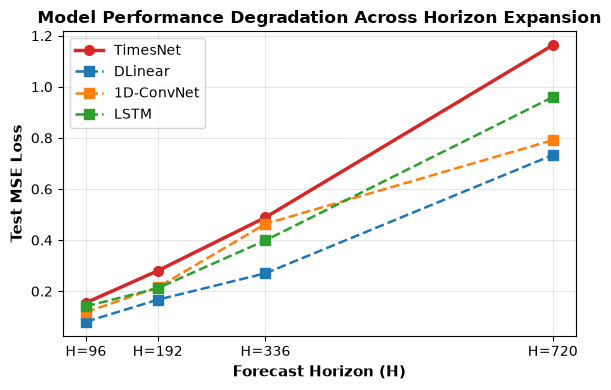

--> Saved horizon comparison plot to: ./plots/fin_horizon_benchmark.png


In [31]:
plot_multi_model_horizon_comparison(
    all_horizon_results,
    horizons,
    save_path="./plots/fin_horizon_benchmark.png"
)

###  Top k ablation

In [32]:
base_args = FinancialConfig()
k_values = [1, 3, 5, 7]

checkpoint_dir = "./checkpoints/topk_ablation"
os.makedirs(checkpoint_dir, exist_ok=True)

metrics_path = os.path.join(checkpoint_dir, "fin_topk_results.npy")

if os.path.exists(metrics_path):
    topk_results = np.load(metrics_path, allow_pickle=True).item()
    print("--> Loaded existing Top-k ablation results from disk.")
else:
    topk_results = {}

print(f"\nRunning Top-k Ablation Study on {device}...")
print(f"Fixed Horizon H = {base_args.pred_len} | k values = {k_values}\n")

force_recompute = False

# ----------------------------------------------------
#  Main Loop Across Top-k Configurations
# ----------------------------------------------------
for k in k_values:
    checkpoint_path = os.path.join(checkpoint_dir, f"TimesNet_exchange_rate_k{k}.pt")
    
    args = copy.deepcopy(base_args)
    args.top_k = k
    args.train_epochs = 7       
    args.model_name = f"TimesNet_k{k}"
    
    model = TimesNet(args).to(device)
    
    if os.path.exists(checkpoint_path) and not force_recompute:
        print(f"--> [FOUND] Loading TimesNet (k={k}) from: {checkpoint_path}")
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        model.eval()
        
        if k not in topk_results:
            print(f"    Evaluating TimesNet (k={k}) on test set...")
            res = train_model(model, args, device)
            topk_results[k] = res
            
    else:
        print(f"\n==================================================")
        print(f"--> [NOT FOUND] Training TimesNet for top_k = {k}...")
        print(f"==================================================")
        
        res = train_model(model, args, device)
        topk_results[k] = res
        
        torch.save(model.state_dict(), checkpoint_path)
        print(f"--> Saved checkpoint to {checkpoint_path}\n")

np.save(metrics_path, topk_results)
print("\n--> Updated and saved complete Top-k ablation results dictionary to:", metrics_path)

--> Loaded existing Top-k ablation results from disk.

Running Top-k Ablation Study on mps...
Fixed Horizon H = 96 | k values = [1, 3, 5, 7]

--> [FOUND] Loading TimesNet (k=1) from: ./checkpoints/topk_ablation/TimesNet_exchange_rate_k1.pt
--> [FOUND] Loading TimesNet (k=3) from: ./checkpoints/topk_ablation/TimesNet_exchange_rate_k3.pt
--> [FOUND] Loading TimesNet (k=5) from: ./checkpoints/topk_ablation/TimesNet_exchange_rate_k5.pt
--> [FOUND] Loading TimesNet (k=7) from: ./checkpoints/topk_ablation/TimesNet_exchange_rate_k7.pt

--> Updated and saved complete Top-k ablation results dictionary to: ./checkpoints/topk_ablation/fin_topk_results.npy



       TIMESNET SENSITIVITY TO PERIOD FREQUENCY DEPTH (K) SUMMARY
top_k Test MSE Test MAE Best Val MSE
  k=1   0.1578   0.2906       0.2054
  k=3   0.1595   0.2874       0.1847
  k=5   0.1516   0.2815       0.1907
  k=7   0.1423   0.2759       0.1914



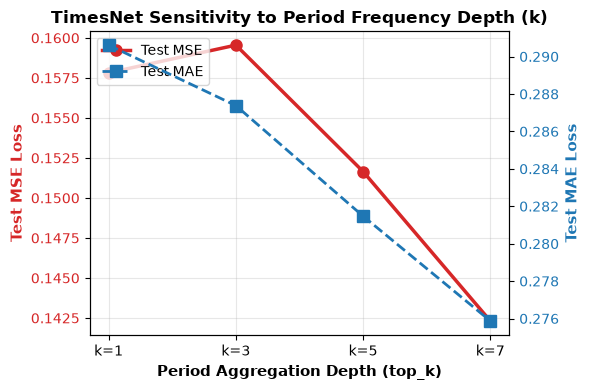

--> Saved plot to: ./plots/fin_topk_ablation.png


In [33]:
summarize_and_plot_experiment(
    results_dict=topk_results,
    param_name="top_k",
    title="TimesNet Sensitivity to Period Frequency Depth (k)",
    xlabel="Period Aggregation Depth (top_k)",
    save_path="./plots/fin_topk_ablation.png",
    plot_type="line",
    prefix="k="
)

### RevIN ablation

In [34]:
base_args = FinancialConfig()
revin_settings = [True, False]

checkpoint_dir = "./checkpoints/revin_ablation"
os.makedirs(checkpoint_dir, exist_ok=True)

metrics_path = os.path.join(checkpoint_dir, "fin_revin_results.npy")

if os.path.exists(metrics_path):
    revin_results = np.load(metrics_path, allow_pickle=True).item()
    print("--> Loaded existing RevIN ablation results from disk.")
else:
    revin_results = {}

print(f"\nRunning RevIN Ablation Study on {device}...")
print(f"Testing RevIN Enabled vs. Disabled | Horizon H = {base_args.pred_len}\n")

force_recompute = False

# ----------------------------------------------------
# Main Loop Across RevIN Configurations
# ----------------------------------------------------
for use_revin in revin_settings:
    setting_name = "With_RevIN" if use_revin else "Without_RevIN"
    checkpoint_path = os.path.join(checkpoint_dir, f"TimesNet_exchange_rate_{setting_name}.pt")
    
    args = copy.deepcopy(base_args)
    args.use_revin = use_revin
    args.train_epochs = 7       
    args.model_name = f"TimesNet_{setting_name}"
    
    model = TimesNet(args).to(device)
    
    if os.path.exists(checkpoint_path) and not force_recompute:
        print(f"--> [FOUND] Loading TimesNet ({setting_name}) from: {checkpoint_path}")
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        model.eval()
        
        if setting_name not in revin_results:
            print(f"    Evaluating TimesNet ({setting_name}) on test set...")
            res = train_model(model, args, device)
            revin_results[setting_name] = res
            
    else:
        print(f"\n==================================================")
        print(f"--> [NOT FOUND] Training TimesNet for {setting_name}...")
        print(f"==================================================")
        
        res = train_model(model, args, device)
        revin_results[setting_name] = res
        
        torch.save(model.state_dict(), checkpoint_path)
        print(f"--> Saved checkpoint to {checkpoint_path}\n")

np.save(metrics_path, revin_results)
print("\n--> Updated and saved complete RevIN ablation results dictionary to:", metrics_path)

--> Loaded existing RevIN ablation results from disk.

Running RevIN Ablation Study on mps...
Testing RevIN Enabled vs. Disabled | Horizon H = 96

--> [FOUND] Loading TimesNet (With_RevIN) from: ./checkpoints/revin_ablation/TimesNet_exchange_rate_With_RevIN.pt
--> [FOUND] Loading TimesNet (Without_RevIN) from: ./checkpoints/revin_ablation/TimesNet_exchange_rate_Without_RevIN.pt

--> Updated and saved complete RevIN ablation results dictionary to: ./checkpoints/revin_ablation/fin_revin_results.npy



       IMPACT OF REVIN ON CONVERGENCE AND TEMPORAL DRIFT SUMMARY
      Setting Test MSE Test MAE Best Val MSE
   With_RevIN   0.1408   0.2745       0.1950
Without_RevIN   2.8213   1.3958       5.3080

--> RevIN Reduced Test Error (MSE) by: 95.01%



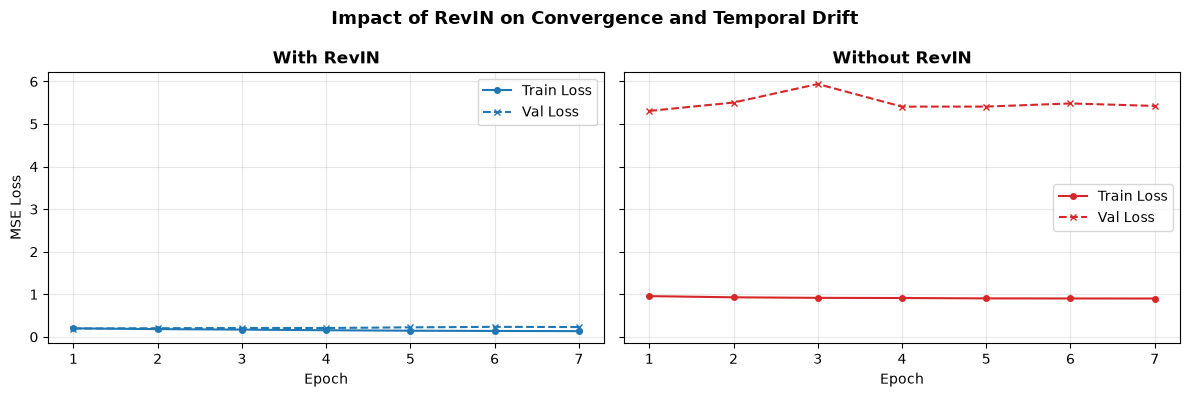

--> Saved plot to: ./plots/fin_revin_ablation.png


In [35]:
summarize_and_plot_experiment(
    results_dict=revin_results,
    param_name="Setting",
    title="Impact of RevIN on Convergence and Temporal Drift",
    save_path="./plots/fin_revin_ablation.png",
    plot_type="trajectories"
)

### FFT frquencies


   TIMESNET FFT DOMAIN INTERPRETABILITY (L=96)
Rank   | Freq Index   | Period (Steps)   | Period (Hours)   | Amplitude 
------------------------------------------------------------------------
1      | 1            | 96.00            | 96.00           h | 52.1636   
2      | 2            | 48.00            | 48.00           h | 22.1194   
3      | 3            | 32.00            | 32.00           h | 20.0381   
4      | 5            | 19.20            | 19.20           h | 10.5348   
5      | 4            | 24.00            | 24.00           h | 10.1122   



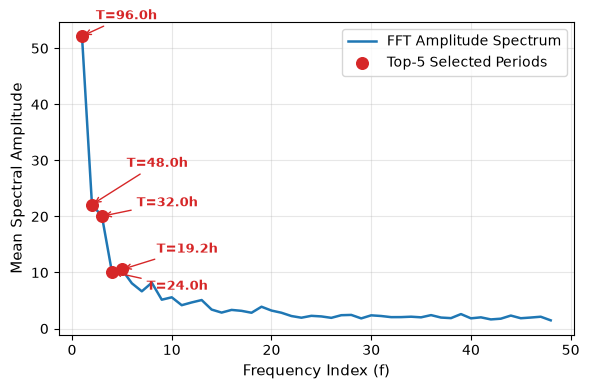

--> Saved FFT Period Analysis Plot to: ./plots/fin_fft_periods.png


In [36]:
model= TimesNet(FinancialConfig()).to(device)
model.load_state_dict(torch.load("./checkpoints/TimesNet_exchange_rate.pt", map_location=device))
model.eval()

with torch.no_grad():
    extract_and_plot_fft_periods(model, fin_test_loader, device, top_k=5, save_path="./plots/fin_fft_periods.png")

## From deterministic to probabilistic forecasting
In finance and energy markets, point forecasts can be misleading because volatility and uncertainty grow the further into the future you predict. Showing a confidence region provides a crucial risk band.

### ELECTRICITY DATASET

In [37]:

prob_args = ElectricityConfig()
prob_args.train_epochs = 10
prob_args.model_name = "Probabilistic_TimesNet"

checkpoint_dir = "./checkpoints/probabilistic"
os.makedirs(checkpoint_dir, exist_ok=True)

checkpoint_path = os.path.join(checkpoint_dir, "Probabilistic_TimesNet_electricity.pt")
metrics_path = os.path.join(checkpoint_dir, "ele_probabilistic_results.npy")

prob_model = ProbabilisticTimesNet(prob_args).to(device)
train_dataset, train_loader = data_provider(prob_args, flag='train')
val_dataset, val_loader = data_provider(prob_args, flag='val')
test_dataset, test_loader = data_provider(prob_args, flag='test')

force_recompute = False

if os.path.exists(checkpoint_path) and not force_recompute:
    print(f"--> [FOUND] Loading Probabilistic TimesNet from: {checkpoint_path}")
    prob_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    prob_model.eval()
    
    if os.path.exists(metrics_path):
        prob_results = np.load(metrics_path, allow_pickle=True).item()
    else:
        prob_results = train_probabilistic_model(prob_model, prob_args, train_loader, val_loader, device)
            
else:
    print(f"\n==================================================")
    print(f"--> [NOT FOUND] Training Probabilistic TimesNet...")
    print(f"==================================================")
    
    prob_results = train_probabilistic_model(prob_model, prob_args, train_loader, val_loader, device)
    
torch.save(prob_model.state_dict(), checkpoint_path)
np.save(metrics_path, prob_results)
print(f"--> Saved checkpoint to {checkpoint_path}")

--> [FOUND] Loading Probabilistic TimesNet from: ./checkpoints/probabilistic/Probabilistic_TimesNet_electricity.pt
--> Saved checkpoint to ./checkpoints/probabilistic/Probabilistic_TimesNet_electricity.pt


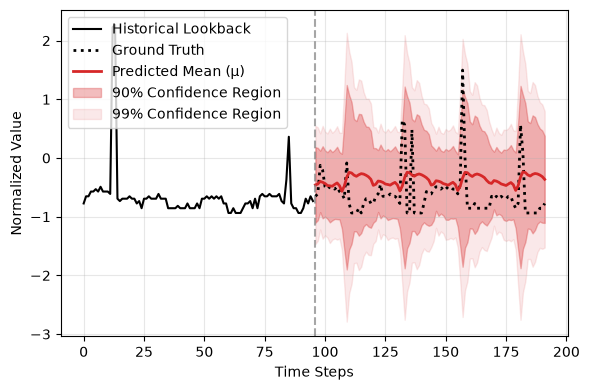

In [38]:

plot_parametric_gaussian_forecast(
    model=prob_model, 
    test_loader=test_loader, 
    device=device, 
    sample_idx=0, 
    channel_idx=0, 
    seq_len=prob_args.seq_len, 
    pred_len=prob_args.pred_len, 
    save_path="./plots/ele_gaussian_forecast.png"
)

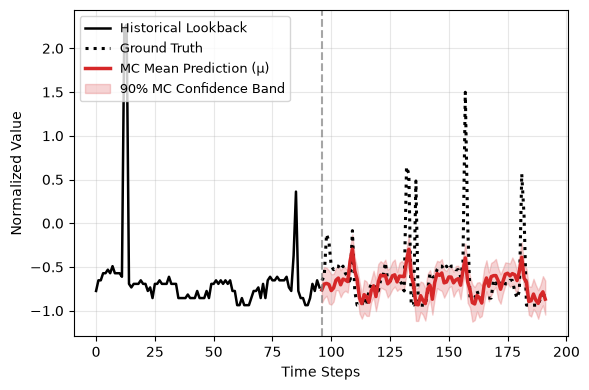

--> Saved MC Dropout forecast plot to: ./plots/ele_mc_dropout_forecast.png


In [39]:
# Load standard TimesNet model (trained on MSE)
base_args = ElectricityConfig()

model = TimesNet(base_args).to(device)
model.load_state_dict(torch.load("./checkpoints/TimesNet_electricity.pt", map_location=device))

# Generate probabilistic MC Dropout plot
plot_mc_dropout_forecast(
    model=model, 
    test_loader=test_loader, 
    device=device, 
    sample_idx=0, 
    channel_idx=0, 
    num_samples=50, 
    num_top_paths=0, 
    save_path="./plots/ele_mc_dropout_forecast.png"
)

### EXCHANGE RATES DATASET

In [40]:

prob_args = FinancialConfig()
prob_args.train_epochs = 10
prob_args.model_name = "Probabilistic_TimesNet"

checkpoint_dir = "./checkpoints/probabilistic"
os.makedirs(checkpoint_dir, exist_ok=True)

checkpoint_path = os.path.join(checkpoint_dir, "Probabilistic_TimesNet_financial.pt")
metrics_path = os.path.join(checkpoint_dir, "fin_probabilistic_results.npy")

prob_model = ProbabilisticTimesNet(prob_args).to(device)
train_dataset, train_loader = data_provider(prob_args, flag='train')
val_dataset, val_loader = data_provider(prob_args, flag='val')
test_dataset, test_loader = data_provider(prob_args, flag='test')

force_recompute = False
if os.path.exists(checkpoint_path) and not force_recompute:
    print(f"--> [FOUND] Loading Probabilistic TimesNet from: {checkpoint_path}")
    prob_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    prob_model.eval()
    
    if os.path.exists(metrics_path):
        prob_results = np.load(metrics_path, allow_pickle=True).item()
    else:
        prob_results = train_probabilistic_model(prob_model, prob_args, train_loader, val_loader, device)
            
else:
    print(f"\n==================================================")
    print(f"--> [NOT FOUND] Training Probabilistic TimesNet...")
    print(f"==================================================")
    
    prob_results = train_probabilistic_model(prob_model, prob_args, train_loader, val_loader, device)
    
torch.save(prob_model.state_dict(), checkpoint_path)
np.save(metrics_path, prob_results)
print(f"--> Saved checkpoint to {checkpoint_path}")

--> [FOUND] Loading Probabilistic TimesNet from: ./checkpoints/probabilistic/Probabilistic_TimesNet_financial.pt
--> Saved checkpoint to ./checkpoints/probabilistic/Probabilistic_TimesNet_financial.pt


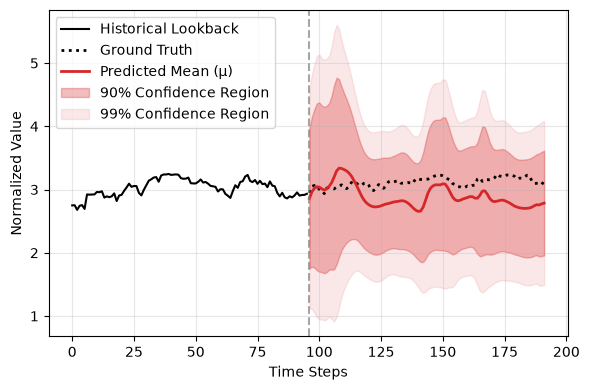

In [41]:

plot_parametric_gaussian_forecast(
    model=prob_model, 
    test_loader=test_loader, 
    device=device, 
    sample_idx=0, 
    channel_idx=0, 
    seq_len=prob_args.seq_len, 
    pred_len=prob_args.pred_len, 
    save_path="./plots/fin_gaussian_forecast.png"
)

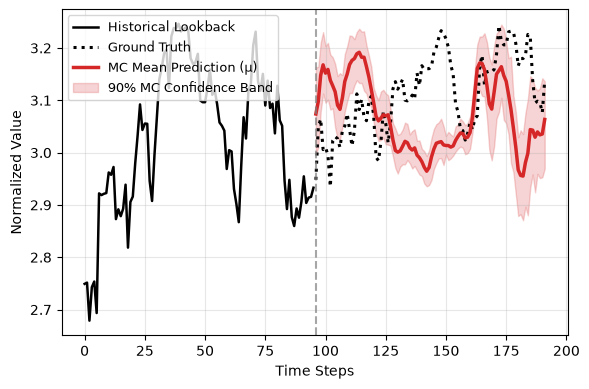

--> Saved MC Dropout forecast plot to: ./plots/fin_mc_dropout_forecast.png


In [42]:
# Load standard TimesNet model (trained on MSE)
base_args = FinancialConfig()

model = TimesNet(base_args).to(device)
model.load_state_dict(torch.load("./checkpoints/TimesNet_exchange_rate.pt", map_location=device))

# Generate probabilistic MC Dropout plot
plot_mc_dropout_forecast(
    model=model, 
    test_loader=test_loader, 
    device=device, 
    sample_idx=0, 
    channel_idx=0, 
    num_samples=50, 
    num_top_paths=0, 
    save_path="./plots/fin_mc_dropout_forecast.png"
)